<a href="https://colab.research.google.com/github/sharvani1357/Road_damage_cnn/blob/main/Road_damage_cnn_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'road-damage-dataset-potholes-cracks-and-manholes' dataset.
Dataset Path:

/kaggle/input/road-damage-dataset-potholes-cracks-and-manholes

Files/Folders Inside Dataset:

['data']

Files/Folders Inside Data Folder:

['COCO-conversion-script.py', 'labels', 'annotations_coco.json', 'README.md', 'YOLO-conversion-script.py', 'images', 'labels-YOLO']

Detected Folders:

['labels', 'images', 'labels-YOLO']

Number of Folders:
3

Sample Label Files:

['vlcsnap-2025-02-19-14h18m48s452.txt', 'vlcsnap-2025-02-19-14h21m29s062.txt', 'vlcsnap_2025-03-16-15h14m35s770.txt', 'vlcsnap-2025-02-18-23h25m45s670.txt', 'vlcsnap-2025-02-19-17h09m41s152.txt']

Sample Label File Content:

2 0.342187 0.558333 0.403125 0.558333 0.403125 0.591667 0.342187 0.591667
2 0.409375 0.561111 0.453125 0.561111 0.453125 0.594444 0.409375 0.594444


Total Images:
2009


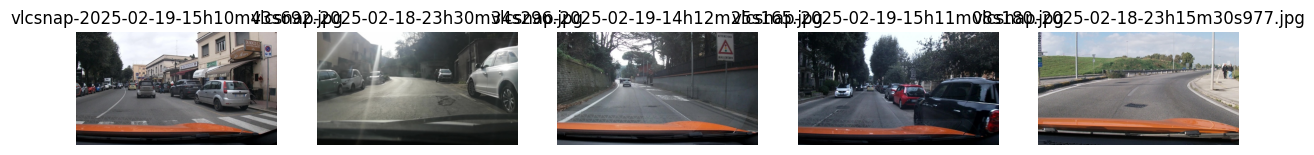


Sample Image Dimensions:

vlcsnap-2025-02-19-15h10m43s692.jpg  -->  (640, 360)
vlcsnap-2025-02-18-23h30m34s296.jpg  -->  (640, 360)
vlcsnap-2025-02-19-14h12m25s165.jpg  -->  (640, 360)
vlcsnap-2025-02-19-15h11m08s180.jpg  -->  (640, 360)
vlcsnap-2025-02-18-23h15m30s977.jpg  -->  (640, 360)

Class Imbalance Analysis:


This dataset contains:
- images folder
- labels folder
- YOLO labels

It is mainly designed for object detection.

For CNN classification,
we will preprocess and create
classification labels later.


TASK 1 COMPLETED SUCCESSFULLY


In [17]:
# ==========================================
# TASK 1 — DATASET UNDERSTANDING
# ==========================================

# ------------------------------------------
# DOWNLOAD DATASET
# ------------------------------------------

import kagglehub

path = kagglehub.dataset_download(
    "lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes"
)

print("Dataset Path:\n")

print(path)

# ------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------

import os
import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

# ------------------------------------------
# CHECK DATASET STRUCTURE
# ------------------------------------------

print("\nFiles/Folders Inside Dataset:\n")

print(os.listdir(path))

# ------------------------------------------
# OPEN DATA FOLDER
# ------------------------------------------

data_path = os.path.join(
    path,
    "data"
)

print("\nFiles/Folders Inside Data Folder:\n")

print(os.listdir(data_path))

# ------------------------------------------
# FIND ONLY FOLDERS
# ------------------------------------------

classes = []

for item in os.listdir(data_path):

    item_path = os.path.join(
        data_path,
        item
    )

    if os.path.isdir(item_path):

        classes.append(item)

print("\nDetected Folders:\n")

print(classes)

print("\nNumber of Folders:")

print(len(classes))

# ------------------------------------------
# LABEL FILES
# ------------------------------------------

labels_path = os.path.join(
    data_path,
    "labels"
)

label_files = os.listdir(labels_path)

print("\nSample Label Files:\n")

print(label_files[:5])

# ------------------------------------------
# READ ONE LABEL FILE
# ------------------------------------------

sample_label = os.path.join(
    labels_path,
    label_files[0]
)

with open(sample_label, "r") as file:

    content = file.read()

print("\nSample Label File Content:\n")

print(content)

# ------------------------------------------
# IMAGE FOLDER
# ------------------------------------------

images_path = os.path.join(
    data_path,
    "images"
)

image_files = os.listdir(images_path)

print("\nTotal Images:")

print(len(image_files))

# ------------------------------------------
# DISPLAY SAMPLE IMAGES
# ------------------------------------------

plt.figure(figsize=(15,5))

for i in range(5):

    image_path = os.path.join(
        images_path,
        image_files[i]
    )

    img = Image.open(image_path)

    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.title(image_files[i])

    plt.axis("off")

plt.show()

# ------------------------------------------
# CHECK IMAGE DIMENSIONS
# ------------------------------------------

print("\nSample Image Dimensions:\n")

for i in range(5):

    image_path = os.path.join(
        images_path,
        image_files[i]
    )

    img = Image.open(image_path)

    print(
        image_files[i],
        " --> ",
        img.size
    )

# ------------------------------------------
# CLASS IMBALANCE ANALYSIS
# ------------------------------------------

print("\nClass Imbalance Analysis:\n")

print("""
This dataset contains:
- images folder
- labels folder
- YOLO labels

It is mainly designed for object detection.

For CNN classification,
we will preprocess and create
classification labels later.
""")

print("\nTASK 1 COMPLETED SUCCESSFULLY")

In [18]:
# ==========================================
# TASK 2 — DATA PREPROCESSING
# ==========================================

# ------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------

from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical

# ------------------------------------------
# DEFINE IMAGE SIZE
# ------------------------------------------

IMG_SIZE = 128

# ------------------------------------------
# IMAGE AND LABEL STORAGE
# ------------------------------------------

X = []

y = []

# ------------------------------------------
# IMAGE PATHS
# ------------------------------------------

images_path = os.path.join(
    data_path,
    "images"
)

labels_path = os.path.join(
    data_path,
    "labels"
)

image_files = os.listdir(images_path)

# ------------------------------------------
# LOAD IMAGES AND LABELS
# ------------------------------------------

for image_name in image_files:

    # Image path

    image_path = os.path.join(
        images_path,
        image_name
    )

    # Read image

    img = cv2.imread(image_path)

    # Resize image

    img = cv2.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )

    # Normalize image

    img = img / 255.0

    # Store image

    X.append(img)

    # --------------------------------------
    # LABEL FILE
    # --------------------------------------

    label_name = image_name.replace(
        ".jpg",
        ".txt"
    )

    label_path = os.path.join(
        labels_path,
        label_name
    )

    # Default label

    class_id = 0

    # Read class label

    if os.path.exists(label_path):

        with open(label_path, "r") as file:

            line = file.readline()

            if line:

                class_id = int(
                    line.split()[0]
                )

    y.append(class_id)

# ------------------------------------------
# CONVERT INTO NUMPY ARRAYS
# ------------------------------------------

X = np.array(X)

y = np.array(y)

# ------------------------------------------
# DISPLAY SHAPES
# ------------------------------------------

print("Image Dataset Shape:\n")

print(X.shape)

print("\nLabel Shape:\n")

print(y.shape)

# ------------------------------------------
# UNIQUE CLASSES
# ------------------------------------------

print("\nUnique Classes:\n")

print(np.unique(y))

# ------------------------------------------
# ONE HOT ENCODING
# ------------------------------------------

y = to_categorical(y)

print("\nEncoded Label Shape:\n")

print(y.shape)

# ------------------------------------------
# TRAIN TEST SPLIT
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------
# DISPLAY TRAIN TEST SHAPES
# ------------------------------------------

print("\nTraining Images:")

print(X_train.shape)

print("\nTesting Images:")

print(X_test.shape)

print("\nTASK 2 COMPLETED SUCCESSFULLY")

Image Dataset Shape:

(2009, 128, 128, 3)

Label Shape:

(2009,)

Unique Classes:

[0 1 2]

Encoded Label Shape:

(2009, 3)

Training Images:
(1607, 128, 128, 3)

Testing Images:
(402, 128, 128, 3)

TASK 2 COMPLETED SUCCESSFULLY


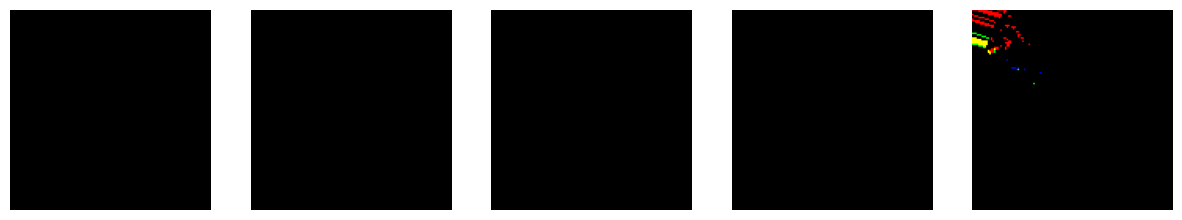

TASK 3 COMPLETED SUCCESSFULLY


In [20]:
# ==========================================
# TASK 3 — DATA AUGMENTATION
# ==========================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ------------------------------------------
# CREATE DATA AUGMENTATION
# ------------------------------------------

datagen = ImageDataGenerator(

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    brightness_range=[0.8, 1.2]

)

# ------------------------------------------
# FIT AUGMENTATION
# ------------------------------------------

datagen.fit(X_train)

# ------------------------------------------
# DISPLAY AUGMENTED IMAGES
# ------------------------------------------

sample_image = X_train[0]

sample_image = np.expand_dims(
    sample_image,
    axis=0
)

plt.figure(figsize=(15,5))

i = 0

for batch in datagen.flow(sample_image,
                          batch_size=1):

    plt.subplot(1,5,i+1)

    plt.imshow((batch[0] * 255).astype("uint8"))

    plt.axis("off")

    i += 1

    if i == 5:
        break

plt.show()

print("TASK 3 COMPLETED SUCCESSFULLY")

In [21]:
# ==========================================
# TASK 4 — CNN ARCHITECTURE DESIGN
# ==========================================

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (Conv2D,MaxPooling2D,Flatten,Dense,Dropout)

# ------------------------------------------
# CREATE CNN MODEL
# ------------------------------------------

model = Sequential()

# ==========================================
# FIRST CONVOLUTION LAYER
# ==========================================

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))

# ------------------------------------------
# FIRST POOLING
# ------------------------------------------

model.add(MaxPooling2D(pool_size=(2,2)))

# ==========================================
# SECOND CONVOLUTION LAYER
# ==========================================

model.add(Conv2D(64,(3,3),activation='relu'))

# ------------------------------------------
# SECOND POOLING
# ------------------------------------------

model.add(MaxPooling2D(pool_size=(2,2)))

# ==========================================
# DROPOUT
# ==========================================

model.add(Dropout(0.25))

# ==========================================
# FLATTEN
# ==========================================

model.add(Flatten())

# ==========================================
# DENSE LAYER
# ==========================================

model.add(Dense(128,activation='relu' ))

# ==========================================
# OUTPUT LAYER
# ==========================================

model.add(Dense(3,activation='softmax'))

# ==========================================
# COMPILE MODEL
# ==========================================

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

# ==========================================
# MODEL SUMMARY
# ==========================================

model.summary()

print("\nTASK 4 COMPLETED SUCCESSFULLY")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,707 (28.20 MB)

 Trainable params: 7,392,707 (28.20 MB)

 Non-trainable params: 0 (0.00 B)


TASK 4 COMPLETED SUCCESSFULLY


In [22]:
# ==========================================
# TASK 5 — MODEL TRAINING
# ==========================================

history = model.fit(
    datagen.flow(
        X_train,
        y_train,
        batch_size=32
    ),

    validation_data=(
        X_test,
        y_test
    ),

    epochs=10
)

print("TASK 5 COMPLETED SUCCESSFULLY")

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 18s 231ms/step - accuracy: 0.4910 - loss: 1.0668 - val_accuracy: 0.3109 - val_loss: 1.0665
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - accuracy: 0.4972 - loss: 1.0421 - val_accuracy: 0.3955 - val_loss: 1.0819
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - accuracy: 0.4941 - loss: 1.0391 - val_accuracy: 0.5050 - val_loss: 1.0679
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.4953 - loss: 1.0368 - val_accuracy: 0.5050 - val_loss: 1.0604
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.4972 - loss: 1.0370 - val_accuracy: 0.4279 - val_loss: 1.0844
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 156ms/step - accuracy: 0.4997 - loss: 1.0292 - val_accuracy: 0.3831 - val_loss: 1.0863
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - accuracy: 0.5047 - loss: 1.0272 - val_accuracy: 0.2139 - val_loss: 1.1992
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step - accuracy: 0.5016 - loss: 1.0287 - val_accuracy: 0

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
Accuracy:

0.22388059701492538

Precision:

0.11868147725446596

Recall:

0.22388059701492538

F1 Score:

0.129535197592967

Classification Report:

              precision    recall  f1-score   support

           0       0.22      0.85      0.34        84
           1       0.00      0.00      0.00       203
           2       0.26      0.17      0.20       115

    accuracy                           0.22       402
   macro avg       0.16      0.34      0.18       402
weighted avg       0.12      0.22      0.13       402


Confusion Matrix:

[[ 71   0  13]
 [161   0  42]
 [ 96   0  19]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

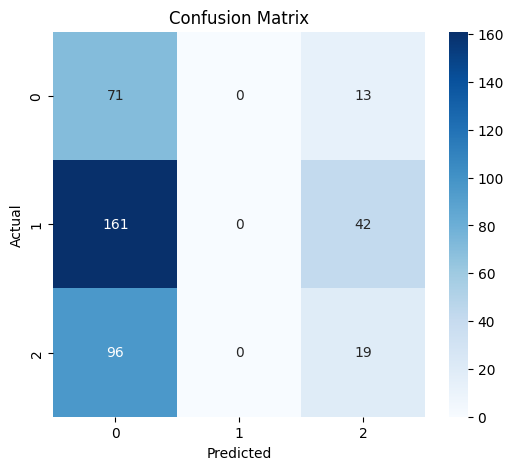

TASK 6 COMPLETED SUCCESSFULLY


In [23]:
# ==========================================
# TASK 6 — MODEL EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns

# ------------------------------------------
# PREDICTIONS
# ------------------------------------------

y_pred = model.predict(X_test)

# Convert probabilities to class labels

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

# ------------------------------------------
# ACCURACY
# ------------------------------------------

accuracy = accuracy_score(
    y_true,
    y_pred_classes
)

print("Accuracy:\n")

print(accuracy)

# ------------------------------------------
# PRECISION
# ------------------------------------------

precision = precision_score(
    y_true,
    y_pred_classes,
    average='weighted'
)

print("\nPrecision:\n")

print(precision)

# ------------------------------------------
# RECALL
# ------------------------------------------

recall = recall_score(
    y_true,
    y_pred_classes,
    average='weighted'
)

print("\nRecall:\n")

print(recall)

# ------------------------------------------
# F1 SCORE
# ------------------------------------------

f1 = f1_score(
    y_true,
    y_pred_classes,
    average='weighted'
)

print("\nF1 Score:\n")

print(f1)

# ------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred_classes
    )
)

# ------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred_classes
)

print("\nConfusion Matrix:\n")

print(cm)

# ------------------------------------------
# VISUALIZE CONFUSION MATRIX
# ------------------------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

print("TASK 6 COMPLETED SUCCESSFULLY")

Total Wrong Predictions:

312


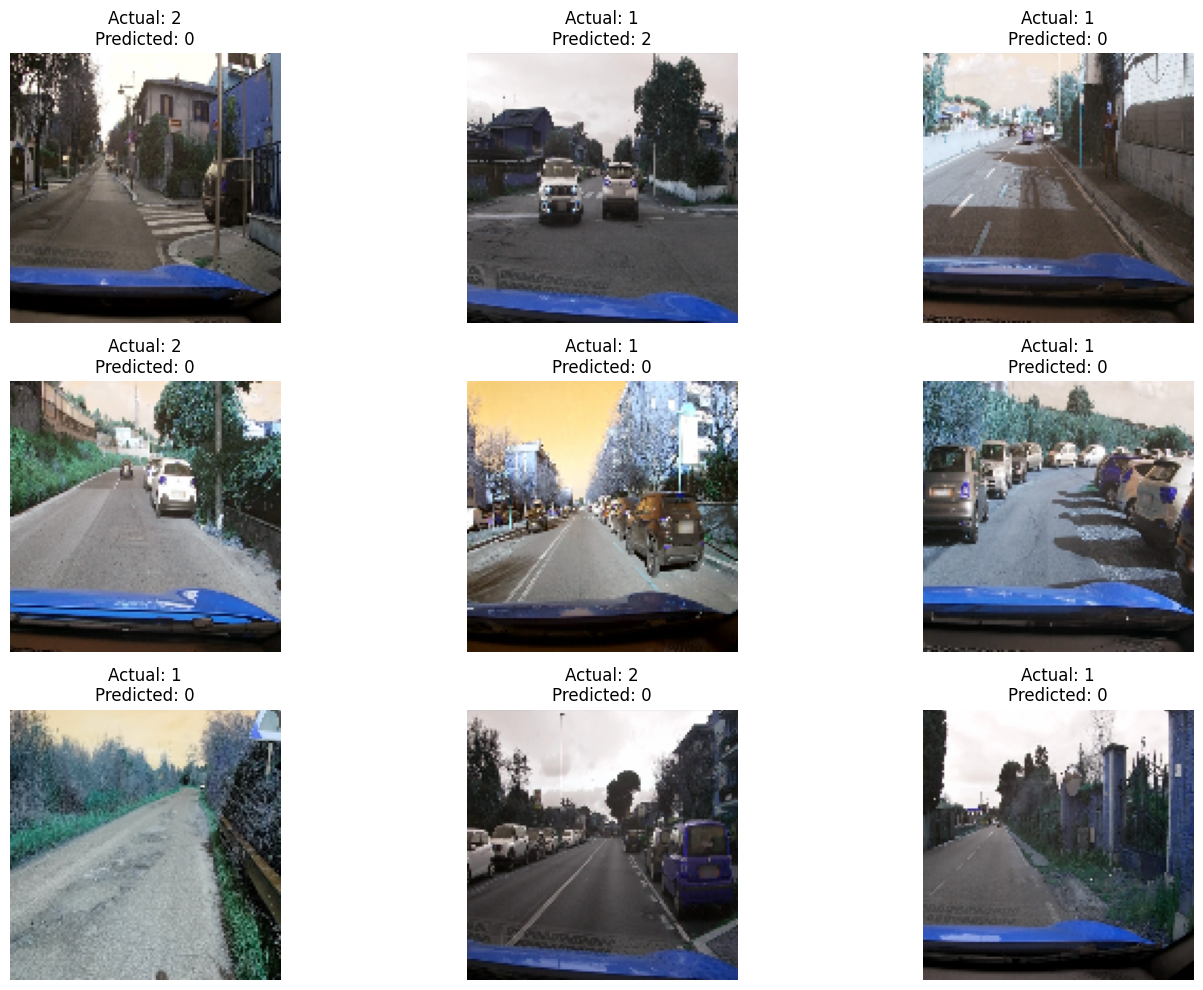

TASK 7 COMPLETED SUCCESSFULLY


In [24]:
# ==========================================
# TASK 7 — ERROR ANALYSIS
# ==========================================

# Get wrongly predicted indices

wrong_indices = np.where(
    y_pred_classes != y_true
)[0]

print("Total Wrong Predictions:\n")

print(len(wrong_indices))

# ------------------------------------------
# DISPLAY WRONG PREDICTIONS
# ------------------------------------------

plt.figure(figsize=(15,10))

for i, idx in enumerate(wrong_indices[:9]):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[idx])

    actual = y_true[idx]

    predicted = y_pred_classes[idx]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

print("TASK 7 COMPLETED SUCCESSFULLY")

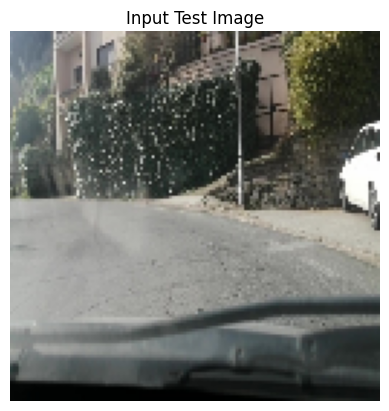

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
Predicted Class:

Class 0

Confidence Score:

0.60684377

Raw Probabilities:

[[0.60684377 0.08005137 0.31310487]]

TASK 8 COMPLETED SUCCESSFULLY


In [25]:
# ==========================================
# TASK 8 — REAL-TIME PREDICTION
# ==========================================

from tensorflow.keras.preprocessing import image

# ------------------------------------------
# CLASS LABELS
# ------------------------------------------

class_names = {

    0: "Class 0",

    1: "Class 1",

    2: "Class 2"

}

# ------------------------------------------
# SELECT TEST IMAGE
# ------------------------------------------

test_image_path = os.path.join(
    images_path,
    image_files[10]
)

# ------------------------------------------
# LOAD IMAGE
# ------------------------------------------

img = image.load_img(
    test_image_path,
    target_size=(128,128)
)

# ------------------------------------------
# DISPLAY IMAGE
# ------------------------------------------

plt.imshow(img)

plt.title("Input Test Image")

plt.axis("off")

plt.show()

# ------------------------------------------
# CONVERT IMAGE TO ARRAY
# ------------------------------------------

img_array = image.img_to_array(img)

# ------------------------------------------
# NORMALIZATION
# ------------------------------------------

img_array = img_array / 255.0

# ------------------------------------------
# ADD EXTRA DIMENSION
# ------------------------------------------

img_array = np.expand_dims(
    img_array,
    axis=0
)

# ------------------------------------------
# MODEL PREDICTION
# ------------------------------------------

prediction = model.predict(img_array)

# ------------------------------------------
# PREDICTED CLASS
# ------------------------------------------

predicted_class = np.argmax(prediction)

# ------------------------------------------
# CONFIDENCE SCORE
# ------------------------------------------

confidence = np.max(prediction)

# ------------------------------------------
# DISPLAY RESULT
# ------------------------------------------

print("Predicted Class:\n")

print(class_names[predicted_class])

print("\nConfidence Score:\n")

print(confidence)

print("\nRaw Probabilities:\n")

print(prediction)

print("\nTASK 8 COMPLETED SUCCESSFULLY")

In [26]:
# ==========================================
# TASK 9 — SAVE CNN MODEL
# ==========================================

import json

# ------------------------------------------
# SAVE COMPLETE MODEL
# ------------------------------------------

model.save("road_damage_cnn_model.h5")

print("Model Saved Successfully")

# ------------------------------------------
# SAVE MODEL WEIGHTS
# ------------------------------------------

model.save_weights(
    "road_damage_weights.weights.h5"
)

print("Weights Saved Successfully")

# ------------------------------------------
# SAVE LABEL MAPPINGS
# ------------------------------------------

class_names = {

    0: "Class 0",

    1: "Class 1",

    2: "Class 2"

}

with open(
    "label_mapping.json",
    "w"
) as file:

    json.dump(
        class_names,
        file
    )

print("Label Mapping Saved Successfully")

print("\nTASK 9 COMPLETED SUCCESSFULLY")

Model Saved Successfully
Weights Saved Successfully
Label Mapping Saved Successfully

TASK 9 COMPLETED SUCCESSFULLY


In [27]:
from google.colab import files

files.download("road_damage_cnn_model.h5")

files.download("road_damage_weights.weights.h5")

files.download("label_mapping.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>